# Model Evaluation - ChatKasir
- Nama: Achmad Rif'an
- Bagian: AI-1 (Model Architect)

## Import Library

In [1]:
import re
import json
import numpy as np
import tensorflow as tf
import tokenizers
import sklearn
import seaborn as sns
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from google.colab import drive
from tokenizers import Tokenizer
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from tensorflow.keras.layers import Dense, LayerNormalization, Dropout, MultiHeadAttention

drive.mount('/content/drive')

# verifikasi versi
print(f"TensorFlow   : {tf.__version__}")
print(f"Tokenizers   : {tokenizers.__version__}")
print(f"Scikit-Learn : {sklearn.__version__}")
print(f"Numpy        : {np.__version__}")
print(f"Pandas       : {pd.__version__}")
print(f"Matplotlib   : {matplotlib.__version__}")
print(f"Seaborn      : {sns.__version__}")

# check GPU yang tersedia
print(f"GPU tersedia: {len(tf.config.list_physical_devices('GPU')) > 0}")

Mounted at /content/drive
TensorFlow   : 2.20.0
Tokenizers   : 0.22.2
Scikit-Learn : 1.6.1
Numpy        : 2.0.2
Pandas       : 2.2.2
Matplotlib   : 3.10.0
Seaborn      : 0.13.2
GPU tersedia: True


## Loading Assets

In [2]:
# 1. Menentukan Path
data_path = "/content/drive/MyDrive/ChatKasir/assets/data/dataset_chatkasir.npz"
tokenizer_path = "/content/drive/MyDrive/ChatKasir/assets/tokenizers/tokenizer.json"
model_path = "/content/drive/MyDrive/ChatKasir/assets/models/chatkasir_model.keras"

# 2. Memuat Data Test
# hanya memanggil 'X_test' dan 'Y_ner_test'
print("1. Memuat Dataset Uji...")
data = np.load(data_path)
X_test = data['X_test']
Y_test = data['Y_ner_test']

print(f"Dimensi Input (X_test) : {X_test.shape}")
print(f"Dimensi Label (Y_test) : {Y_test.shape}")

# 3. Memuat Tokenizer
print("\n2. Memuat Tokenizer...")
tokenizer = Tokenizer.from_file(tokenizer_path)
print(f"Ukuran Kosakata (Vocab): {tokenizer.get_vocab_size()} token")

# 4. Mendefinisikan ulang Custom Layer
@tf.keras.utils.register_keras_serializable()
class TransformerEncoder(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1, **kwargs):
        super(TransformerEncoder, self).__init__(**kwargs)
        self.supports_masking = True
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.rate = rate

        self.att = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([Dense(ff_dim, activation="relu"), Dense(embed_dim)])
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training=False, mask=None):
        padding_mask = tf.cast(mask[:, tf.newaxis, :], dtype=tf.int32) if mask is not None else None
        attn_output = self.att(inputs, inputs, attention_mask=padding_mask)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

    def get_config(self):
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "ff_dim": self.ff_dim,
            "rate": self.rate,
        })
        return config

# 5. Memuat model AI menggunakan fungsi standar Keras
print("\n3. Memuat Model AI (.keras)...")
# Menggunakan load_model ditambah parameter custom_objects
model = tf.keras.models.load_model(
    model_path,
    compile=False,
    custom_objects={'TransformerEncoder': TransformerEncoder}
)

print("Model berhasil dimuat")
print("\n" + "-"*50)

model.summary()

1. Memuat Dataset Uji...
Dimensi Input (X_test) : (10000, 128)
Dimensi Label (Y_test) : (10000, 128)

2. Memuat Tokenizer...
Ukuran Kosakata (Vocab): 5000 token

3. Memuat Model AI (.keras)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'transformer_encoder', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'transformer_encoder_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model berhasil dimuat

--------------------------------------------------


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_ids           │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 128, 128)  │    640,000 │ input_ids[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 128)       │          0 │ input_ids[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encoder │ (None, 128, 128)  │    330,240 │ embedding[0][0],  │
│ (TransformerEncode… │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, 128, 128)  │    330,240 │ transformer_enco… │
│ (TransformerEncode… │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 128, 128)  │     98,816 │ transformer_enco… │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ner_output (Dense)  │ (None, 128, 7)    │        903 │ bidirectional[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,400,199 (5.34 MB)

 Trainable params: 1,400,199 (5.34 MB)

 Non-trainable params: 0 (0.00 B)

## Evaluasi Metriks

In [3]:
print("Model sedang memprediksi X_test...")

# 1. Memprediksi data X_test
y_pred_probs = model.predict(X_test, batch_size=32)

# 2. Ambil ID Tag (0-6) dari probabilitas tertinggi
y_pred_tags = np.argmax(y_pred_probs, axis=-1)

# 3. Pembersihan Padding (hanya evaluasi kata asli)
mask_kata_asli = X_test != 0

# 4. Flatten matriks untuk dibandingkan secara 1 per 1 kata
y_true_bersih = Y_test[mask_kata_asli]
y_pred_bersih = y_pred_tags[mask_kata_asli]

# 5. Laporan Evaluasi
# fokus pada tag entitas (1-6)
label_id = [1, 2, 3, 4, 5, 6]
label_name = ['B-PROD', 'I-PROD', 'B-QTY', 'I-QTY', 'B-PRICE', 'I-PRICE']

laporan = classification_report(
    y_true_bersih,
    y_pred_bersih,
    labels=label_id,
    target_names=label_name,
    digits=4,
    zero_division=0
)

print("LAPORAN EVALUASI DATA TEST:")
print("-" * 50)
print(laporan)

Model sedang memprediksi X_test...
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step
LAPORAN EVALUASI DATA TEST:
--------------------------------------------------
              precision    recall  f1-score   support

      B-PROD     0.9999    0.9999    0.9999     12025
      I-PROD     0.9999    1.0000    0.9999     26185
       B-QTY     0.9912    0.9997    0.9955     11829
       I-QTY     1.0000    1.0000    1.0000       723
     B-PRICE     0.9996    1.0000    0.9998     16710
     I-PRICE     0.9995    1.0000    0.9997     16491

   micro avg     0.9985    0.9999    0.9992     83963
   macro avg     0.9983    0.9999    0.9991     83963
weighted avg     0.9985    0.9999    0.9992     83963



## Visualisasi Confusion Matrix

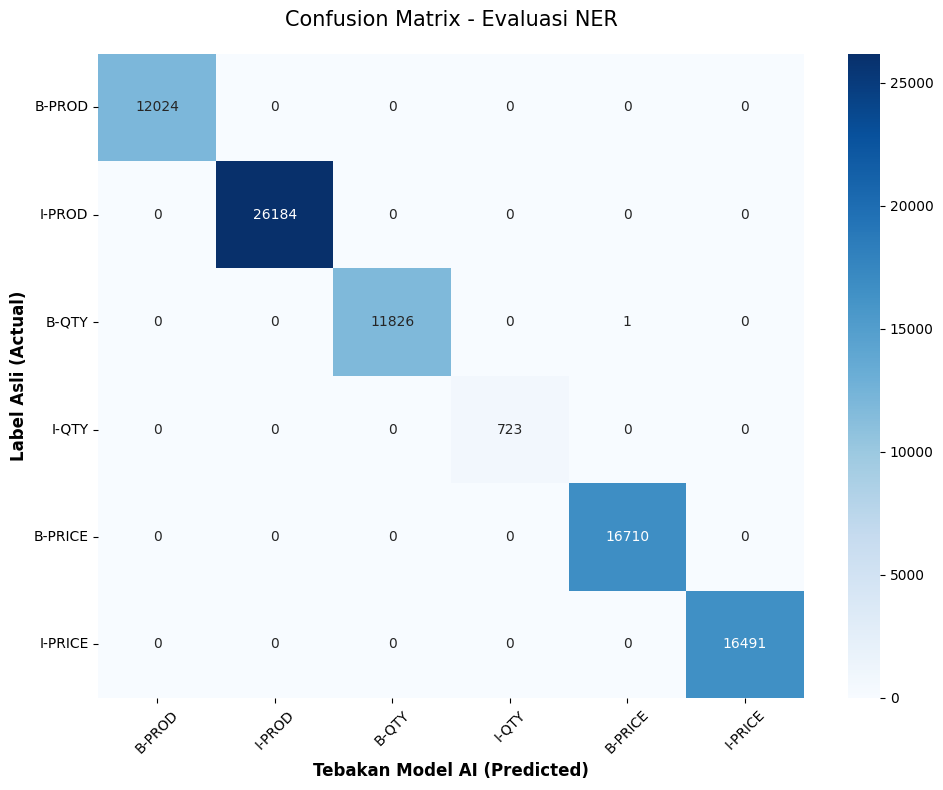

In [4]:
# 1. Menghitung Confusion Matrix
# Membandingkan kunci jawaban (y_true) dengan tebakan model (y_pred)
# hanya fokus pada label entitas
cm = confusion_matrix(y_true_bersih, y_pred_bersih, labels=label_id)

# 2. Ukuran canvas
plt.figure(figsize=(10, 8))

# 3. Heatmap menggunakan seaborn
# annot=True : menampilkan angka di dalam kotak
# fmt='d'    : format angka desimal biasa (bukan scientific)
# cmap       : pilihan warna (Blues = degradasi biru)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_name,
    yticklabels=label_name
)

# 4. Memberikan judul dan label sumbu
plt.title('Confusion Matrix - Evaluasi NER', fontsize=15, pad=20)
plt.xlabel('Tebakan Model AI (Predicted)', fontsize=12, fontweight='bold')
plt.ylabel('Label Asli (Actual)', fontsize=12, fontweight='bold')

# 5. Memutar teks label sumbu X agar tidak saling bertumpuk
plt.xticks(rotation=45)
plt.yticks(rotation=0)

# 6. Menampilkan plot
plt.tight_layout()
plt.show()

## Error Analysis

In [5]:
print("Mencari kalimat di mana AI melakukan kesalahan...\n")

# 1. Mendefinisikan ulang kamus Tag (agar angka 0-6 bisa dibaca manusia)
id2tag = {
    0: "O", 1: "B-PROD", 2: "I-PROD", 3: "B-QTY",
    4: "I-QTY", 5: "B-PRICE", 6: "I-PRICE"
}

jumlah_error_ditemukan = 0
batas_error_ditampilkan = 5

# 2. Looping menelusuri data test satu per satu dari atas ke bawah
for i in range(len(X_test)):
    # Ambil baris data ke-i
    token_ids = X_test[i]
    true_tags = Y_test[i]
    pred_tags = y_pred_tags[i]

    # 3. Buang padding (angka 0), hanya fokus menganalisis kata asli
    mask = token_ids != 0
    token_asli = token_ids[mask]
    true_asli = true_tags[mask]
    pred_asli = pred_tags[mask]

    # 4. Deteksi Error: bandingkan kunci jawaban dengan tebakan AI
    if not np.array_equal(true_asli, pred_asli):
        jumlah_error_ditemukan += 1

        # 5. Terjemahkan ID kembali menjadi format teks
        # Mengubah [15, 230, ...] menjadi ["nasi", "goreng", ...]
        kata_kata = [tokenizer.id_to_token(t).replace("##", "") for t in token_asli]

        # Mengubah [1, 2, ...] menjadi ["B-PROD", "I-PROD", ...]
        label_asli = [id2tag[tag] for tag in true_asli]
        label_tebakan = [id2tag[tag] for tag in pred_asli]

        # 6. Tampilkan hasil ke dalam format tabel
        print(f"ERROR KASUS KE-{jumlah_error_ditemukan}")
        df_error = pd.DataFrame({
            "Kata (Token)": kata_kata,
            "Kunci Jawaban (True)": label_asli,
            "Tebakan AI (Pred)": label_tebakan
        })

        df_error['Status'] = df_error.apply(
            lambda row: "V" if row['Kunci Jawaban (True)'] == row['Tebakan AI (Pred)'] else "SALAH",
            axis=1
        )

        print(df_error.to_string(index=False))
        print("-" * 65 + "\n")

    # Berhenti mencari jika sudah menemukan 5 kasus
    if jumlah_error_ditemukan >= batas_error_ditampilkan:
        break

if jumlah_error_ditemukan == 0:
    print("Model AI tidak membuat satu pun kesalahan pada data test")

Mencari kalimat di mana AI melakukan kesalahan...

ERROR KASUS KE-1
Kata (Token) Kunci Jawaban (True) Tebakan AI (Pred) Status
       order                    O                 O      V
           4                B-QTY             B-QTY      V
      pempek               B-PROD            B-PROD      V
           ,                    O                 O      V
       terus                    O                 O      V
        nasi               B-PROD            B-PROD      V
      goreng               I-PROD            I-PROD      V
       sosis               I-PROD            I-PROD      V
       telur               I-PROD            I-PROD      V
         nya                    O                 O      V
           4                    O             B-QTY  SALAH
          ya                    O                 O      V
       [SEP]                    O                 O      V
        siap                    O                 O      V
         kak                    O              

## Simulasi End-to-End

In [6]:
# 1. Fungsi Pembersih Angka
def bersihkan_angka_harga(teks_harga):
    # Mengubah teks gaul (misal: '18rb', '15k') menjadi angka (18000)
    teks = teks_harga.lower().replace('.', '').replace(',', '')

    if 'rb' in teks or 'ribu' in teks or 'k' in teks:
        angka = re.sub(r'[^0-9]', '', teks)
        return int(angka) * 1000 if angka else 0

    angka = re.sub(r'[^0-9]', '', teks)
    return int(angka) if angka else 0

def bersihkan_angka_qty(teks_qty):
    # Mengubah teks ejaan (misal: 'dua', 'semangkok', 'telu') menjadi angka integer
    kamus = {
        # Angka 1 dan variasi satuan wadah/porsi
        "satu": 1, "sebiji": 1, "seporsi": 1, "sebungkus": 1,
        "segelas": 1, "semangkok": 1, "sepiring": 1, "sebotol": 1,
        "secangkir": 1, "setusuk": 1, "sepotong": 1, "siji": 1, "sebox": 1, "sekotak": 1,

        # Angka dasar 2 - 10 serta bahasa gaul/daerah yang umum
        "dua": 2, "loro": 2,
        "tiga": 3, "telu": 3,
        "empat": 4, "mpat": 4, "pat": 4, "papat": 4,
        "lima": 5, "limo": 5,
        "enam": 6, "enem": 6, "nam": 6,
        "tujuh": 7, "pitu": 7,
        "delapan": 8, "lapan": 8, "wolu": 8,
        "sembilan": 9, "sanga": 9, "songo": 9,
        "sepuluh": 10, "sepulu": 10,

        # Angka belasan
        "sebelas": 11, "seblas": 11,
        "dua belas": 12, "selusin": 12,
        "tiga belas": 13,
        "empat belas": 14, "patbelas": 14,
        "lima belas": 15,
        "enam belas": 16, "nambelas": 16,
        "tujuh belas": 17,
        "delapan belas": 18,
        "sembilan belas": 19,

        # Angka puluhan bulat
        "dua puluh": 20, "duapuluh": 20,
        "tiga puluh": 30, "tigapuluh": 30,
        "empat puluh": 40, "empatpuluh": 40,
        "lima puluh": 50, "limapuluh": 50,
        "seratus": 100
    }

    # Normalisasi teks: ubah ke huruf kecil dan buang spasi berlebih di awal/akhir
    teks = teks_qty.lower().strip()

    # Cek apakah teks ejaan ada di kamus
    if teks in kamus:
        return kamus[teks]

    # Jika tidak ada di kamus, cari angka murni di dalam teks (misal: "3pcs" -> 3)
    angka = re.sub(r'[^0-9]', '', teks)
    return int(angka) if angka else 1 # Default 1 jika benar-benar gagal terbaca

# 2. Fungsi Parser BIO ke JSON
def parse_hasil_ai_ke_json(tokens, tags):
    # Menyatukan suku kata yang terpecah oleh Tokenizer (membuang tanda ##)
    clean_tokens, clean_tags = [], []
    for t, tag in zip(tokens, tags):
        if t == "[PAD]": break # abaikan padding kosong
        if t.startswith("##"):
            if clean_tokens: clean_tokens[-1] += t[2:] # sambung kata
        else:
            clean_tokens.append(t)
            clean_tags.append(tag)

    # Ekstraksi independen
    list_produk, list_qty, list_harga = [], [], []
    temp_word = []
    current_tag = None

    # Helper function untuk menyimpan isi buffer ke list yang tepat
    def simpan_entitas(kata_array, tag_jenis):
        kata_gabungan = " ".join(kata_array)
        if tag_jenis == "PROD":
            list_produk.append(kata_gabungan.title())
        elif tag_jenis == "QTY":
            list_qty.append(bersihkan_angka_qty(kata_gabungan))
        elif tag_jenis == "PRICE":
            list_harga.append(bersihkan_angka_harga(kata_gabungan))

    # Looping pembacaan tag
    for kata, tag in zip(clean_tokens, clean_tags):
        if tag == "O":
            if current_tag: # jika tag terputus oleh 'O', simpan buffer
                simpan_entitas(temp_word, current_tag)
                temp_word, current_tag = [], None
            continue

        if tag.startswith("B-"):
            if current_tag: # jika langsung bertemu B- baru, simpan buffer lama
                simpan_entitas(temp_word, current_tag)
            temp_word = [kata]
            current_tag = tag.split("-")[1] # ambil 'PROD', 'QTY', atau 'PRICE'

        elif tag.startswith("I-"):
            jenis_tag = tag.split("-")[1]
            if current_tag == jenis_tag:
                temp_word.append(kata) # lanjutkan menumpuk kata
            else:
                # jika anomali (I- muncul tanpa B-), perlakukan seperti B-
                if current_tag:
                    simpan_entitas(temp_word, current_tag)
                temp_word = [kata]
                current_tag = jenis_tag

    # Simpan isi buffer terakhir saat kalimat habis
    if current_tag and temp_word:
        simpan_entitas(temp_word, current_tag)

    # Mapping berdasarkan urutan
    items = []
    for i in range(len(list_produk)):
        # Ambil Qty sesuai urutan (jika user tidak sebut qty, default 1)
        qty = list_qty[i] if i < len(list_qty) else 1

        # Ambil Harga sesuai urutan dari penjual
        price = list_harga[i] if i < len(list_harga) else 0

        # Hitung Subtotal
        subtotal = qty * price

        items.append({
            "product": list_produk[i],
            "quantity": qty,
            "price_satuan": price,
            "subtotal": subtotal
        })

    return items

# 3. Fungsi Utama (menerima teks -> mengembalikan JSON)
def proses_pesanan_masuk(teks_chat):
    # Tokenisasi kalimat pembeli
    encoded = tokenizer.encode(teks_chat)
    input_ids = encoded.ids
    tokens = encoded.tokens

    # Padding dan Truncating
    max_len = 128
    if len(input_ids) > max_len:
        input_ids = input_ids[:max_len]
        tokens = tokens[:max_len]
    else:
        selisih = max_len - len(input_ids)
        input_ids = input_ids + [tokenizer.token_to_id("[PAD]")] * selisih
        tokens = tokens + ["[PAD]"] * selisih

    # Ubah ke matriks 2D dan suruh Model menebak
    input_matriks = np.array([input_ids])
    pred_probs = model.predict(input_matriks, verbose=0)
    pred_tags_id = np.argmax(pred_probs, axis=-1)[0]

    # Terjemahkan ID angka menjadi teks tag BIO
    id2tag = {0: "O", 1: "B-PROD", 2: "I-PROD", 3: "B-QTY", 4: "I-QTY", 5: "B-PRICE", 6: "I-PRICE"}
    pred_tags_teks = [id2tag[tag_id] for tag_id in pred_tags_id]

    # Format ke JSON
    hasil_akhir = parse_hasil_ai_ke_json(tokens, pred_tags_teks)
    return hasil_akhir

# Uji Coba
chat_pembeli = "mas pesen 3 porsi ayam geprek dan 2 es teh [SEP] siap kak ayam geprek harganya 12rb dan es teh harganya 3rb totalnya 42rb ya"

print(f"Teks Pembeli: '{chat_pembeli}'")
print("-" * 50)

# Panggil fungsi AI
hasil_kasir = proses_pesanan_masuk(chat_pembeli)

# Cetak format JSON
print("DATA STRUKTUR (RESPONSE API):")
print(json.dumps(hasil_kasir, indent=4))

# Simulasi hitung total tagihan keseluruhan
total_bayar = sum(item['subtotal'] for item in hasil_kasir)
print("-" * 50)
print(f"TOTAL PEMBAYARAN: Rp {total_bayar:,}".replace(',', '.'))

Teks Pembeli: 'mas pesen 3 porsi ayam geprek dan 2 es teh [SEP] siap kak ayam geprek harganya 12rb dan es teh harganya 3rb totalnya 42rb ya'
--------------------------------------------------
DATA STRUKTUR (RESPONSE API):
[
    {
        "product": "Ayam Geprek",
        "quantity": 3,
        "price_satuan": 12000,
        "subtotal": 36000
    },
    {
        "product": "Es Teh",
        "quantity": 2,
        "price_satuan": 3000,
        "subtotal": 6000
    }
]
--------------------------------------------------
TOTAL PEMBAYARAN: Rp 42.000


## Kesimpulan

1. Performa Metrik yang Nyaris Sempurna: Model mencapai F1-Score sebesar 99.91% (Macro Avg). Ini berarti model hampir tidak pernah salah dalam menebak mana yang merupakan Produk, Kuantitas, maupun Harga.

2. AI Lebih Pintar dari Data Latih (Error Analysis): Jika mengamati 5 kasus "Error" yang dicetak, model sebenarnya menebak dengan benar (mengubah label O menjadi B-QTY untuk angka seperti "4", "5", dan kata "seporsi"). "Kesalahan" ini terjadi murni karena data pengujian (kunci jawaban) luput memberi label pada angka tersebut saat proses pembuatan data. Ini adalah bukti nyata bahwa model AI telah melakukan Generalization (pemahaman konteks), bukan sekadar menghafal

3. Simulasi End-to-End Sukses: Teks majemuk "3 ayam geprek 12rb dan 2 es teh 3rb total 42rb" berhasil dipetakan ke dalam struktur JSON yang akurat dengan relasi perhitungan subtotal yang presisi (Rp 42.000). Bug penggabungan "32" dan harga yang sebelumnya gagal ditangkap kini sudah teratasi.